# Stage 4 — Pareto Uncertainty Analysis (Equifinality)

Quantifies predictive uncertainty arising from equifinality in the Pareto front.
All data are read from the existing caches — **no new SWMM runs**.

| Section | Content |
|---------|--------|
| 1 | Parameter spread across Pareto solutions |
| 2 | Uncertainty scatter plot (obs vs sim with Pareto error bars) |
| 3 | Envelope hydrographs (fill\_between over all Pareto members) |
| 4 | P-factor and envelope width metrics |

| Input | Path |
|-------|------|
| Full Pareto ensemble | `outputs/pareto/final/pareto_ensemble_full.csv` |
| Single optimum | `outputs/pareto/final/pareto_optimum.csv` |
| Calibration cache | `outputs/results/loocv/loocv_calibration_cache.pkl` |
| Objectives cache | `outputs/results/final_calibration/combined_objectives.pkl` |

| Output | Path |
|--------|------|
| Parameter spread plot | `outputs/metrics/pareto_parameter_spread.png` |
| Uncertainty scatter | `outputs/metrics/pareto_uncertainty_scatter.png` |
| Uncertainty hydrographs | `outputs/metrics/uncertainty_hydrographs/` |
| Metrics table | printed below |

In [9]:
# ── Configuration ────────────────────────────────────────────────────────────
import sys
from pathlib import Path

sys.path.insert(0, str(Path('.').resolve()))

PROJECT_ROOT  = Path('.')
LOOCV_DIR     = PROJECT_ROOT / 'outputs' / 'results' / 'loocv'
FINAL_DIR     = PROJECT_ROOT / 'outputs' / 'results' / 'final_calibration'
PARETO_DIR    = PROJECT_ROOT / 'outputs' / 'pareto'  / 'final'
METRICS_DIR   = PROJECT_ROOT / 'outputs' / 'metrics'
UNCERT_DIR    = METRICS_DIR  / 'uncertainty_hydrographs'

UNCERT_DIR.mkdir(parents=True, exist_ok=True)

CALIBRATION_CACHE   = LOOCV_DIR  / 'loocv_calibration_cache.pkl'
OBJECTIVES_CACHE    = FINAL_DIR  / 'combined_objectives.pkl'
PARETO_ENSEMBLE_CSV = PARETO_DIR / 'pareto_ensemble_full.csv'
PARETO_OPTIMUM_CSV  = PARETO_DIR / 'pareto_optimum.csv'

for _p, _label in [
    (CALIBRATION_CACHE,   'Calibration cache'),
    (OBJECTIVES_CACHE,    'Objectives cache'),
    (PARETO_ENSEMBLE_CSV, 'Pareto ensemble CSV'),
    (PARETO_OPTIMUM_CSV,  'Pareto optimum CSV'),
]:
    if not _p.exists():
        raise FileNotFoundError(
            f'{_label} not found: {_p}\n'
            'Run 03_Final_Calibration.ipynb first.'
        )

print('NB4  -  Pareto Uncertainty Analysis')
print(f'Uncertainty hydrographs -> {UNCERT_DIR}')


NB4  -  Pareto Uncertainty Analysis
Uncertainty hydrographs -> outputs\metrics\uncertainty_hydrographs


In [10]:
# ── Imports ───────────────────────────────────────────────────────────────────
import pickle
import logging

import numpy as np
import pandas as pd
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s %(levelname)-8s %(name)s: %(message)s',
    datefmt='%H:%M:%S',
)
logger = logging.getLogger('nb4_pareto_uncertainty')

TITLE_FONT = {'fontsize': 18, 'fontweight': 'bold'}
LABEL_FONT = {'fontsize': 16, 'fontweight': 'normal'}
TICK_FONT  = {'labelsize': 14}

print('Imports complete.')


Imports complete.


In [11]:
# ── Load Pareto ensemble and calibration data ─────────────────────────────────

# Full Pareto ensemble: 12 rows × 77 columns (Factors + per-event SWMM stats)
ensemble_df = pd.read_csv(PARETO_ENSEMBLE_CSV, header=[0, 1], index_col=0)
optimum_df  = pd.read_csv(PARETO_OPTIMUM_CSV,  header=[0, 1], index_col=0)

pareto_indices = ensemble_df.index.tolist()
optimum_idx    = int(optimum_df.index[0])
n_pareto       = len(pareto_indices)
# Pareto members excluding the single chosen optimum
rest_indices   = [i for i in pareto_indices if i != optimum_idx]

logger.info('Pareto front: %d members, optimum index=%d', n_pareto, optimum_idx)

# Observed hydrographs from the LOOCV calibration cache
with open(CALIBRATION_CACHE, 'rb') as _f:
    _cache = pickle.load(_f)
obs_hydrograph_df = _cache['obs_hydrograph_df']

# Full merged calibration + hydrograph data from the objectives cache
with open(OBJECTIVES_CACHE, 'rb') as _f:
    _oc = pickle.load(_f)
cali_merged  = _oc['cali_merged']   # 1323 rows × 77 cols
hydro_merged = _oc['hydro_merged']  # 1323 rows × 4548 cols

logger.info('cali_merged : %s', cali_merged.shape)
logger.info('hydro_merged: %s', hydro_merged.shape)

print(f'Pareto front size : {n_pareto} members')
print(f'Pareto indices    : {pareto_indices}')
print(f'Optimum index     : {optimum_idx}')
print(f'cali_merged shape : {cali_merged.shape}')
print(f'hydro_merged shape: {hydro_merged.shape}')


11:52:19 INFO     nb4_pareto_uncertainty: Pareto front: 12 members, optimum index=708


11:52:19 INFO     nb4_pareto_uncertainty: cali_merged : (1323, 77)
11:52:19 INFO     nb4_pareto_uncertainty: hydro_merged: (1323, 4548)


Pareto front size : 12 members
Pareto indices    : [682, 701, 708, 709, 710, 717, 718, 719, 727, 728, 898, 917]
Optimum index     : 708
cali_merged shape : (1323, 77)
hydro_merged shape: (1323, 4548)


=== Factor spread across the Pareto front ===

                        Min   Max  Median  Range  N_uniq
Imperviousness factor   1.0   1.1     1.0    0.1       2
Storage factor          5.0   7.0     7.0    2.0       2
Width factor            0.7   1.3     1.0    0.6       3
Manning n factor        1.0   1.0     1.0    0.0       1
Pct. zero factor        1.0   1.0     1.0    0.0       1
CN factor               1.0   1.0     1.0    0.0       1
Pct. routed [%]        35.0  45.0    40.0   10.0       3
Evaporation [mm/d]      4.0   4.0     4.0    0.0       1



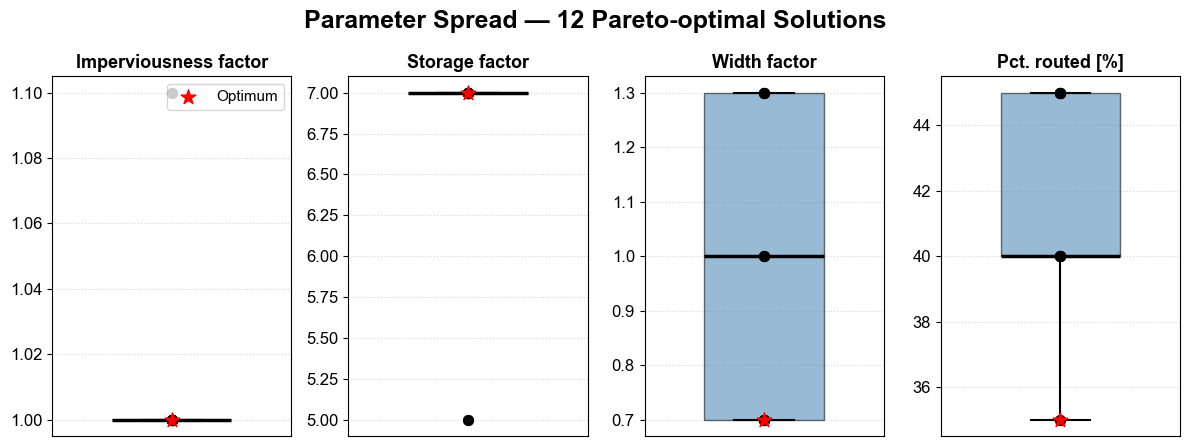

Saved -> outputs\metrics\pareto_parameter_spread.png


In [12]:
# ── Section 1: Parameter Spread Across the Pareto Front ──────────────────────

VARIABLE_PARAMS = ['IMP', 'Storage', 'Width', 'PCT_ROUTED']
FIXED_PARAMS    = ['N', 'PCT_ZERO', 'CN', 'EVAP']
PARAM_LABELS    = {
    'IMP':       'Imperviousness factor',
    'Storage':   'Storage factor',
    'Width':     'Width factor',
    'PCT_ROUTED':'Pct. routed [%]',
    'N':         'Manning n factor',
    'PCT_ZERO':  'Pct. zero factor',
    'CN':        'CN factor',
    'EVAP':      'Evaporation [mm/d]',
}

factor_df = ensemble_df['Factors']  # shape: (n_pareto, 8)

# Summary table: all 8 parameters
summary = factor_df.agg(['min', 'max', 'median']).T.round(4)
summary.columns = ['Min', 'Max', 'Median']
summary['Range']  = (summary['Max'] - summary['Min']).round(4)
summary['N_uniq'] = [int(factor_df[c].nunique()) for c in factor_df.columns]
summary.index     = [PARAM_LABELS.get(c, c) for c in factor_df.columns]

print('=== Factor spread across the Pareto front ===\n')
print(summary.to_string())
print()

plt.rcParams['font.family'] = 'Arial'

# Boxplot for variable parameters (fixed ones have zero spread — excluded)
fig, axes = plt.subplots(1, len(VARIABLE_PARAMS), figsize=(12, 4.5), sharey=False)

for ax, col in zip(axes, VARIABLE_PARAMS):
    vals = factor_df[col].values.astype(float)
    ax.boxplot(
        vals, patch_artist=True, widths=0.5,
        boxprops   =dict(facecolor='steelblue', alpha=0.55),
        medianprops=dict(color='black', linewidth=2.5),
        whiskerprops=dict(linewidth=1.5),
        capprops   =dict(linewidth=1.5),
    )
    # Overlay individual solution dots
    ax.scatter([1] * len(vals), vals, color='black', s=50, zorder=4, alpha=0.8)
    # Highlight the optimum
    opt_val = float(ensemble_df.loc[optimum_idx, ('Factors', col)])
    ax.scatter([1], [opt_val], color='red', s=120, zorder=5,
               marker='*', label='Optimum')
    ax.set_title(PARAM_LABELS.get(col, col), fontsize=13, fontweight='bold')
    ax.tick_params(axis='y', labelsize=12)
    ax.set_xticks([])
    ax.grid(True, axis='y', linestyle=':', alpha=0.5)

axes[0].legend(fontsize=11, loc='upper right')
fig.suptitle(
    f'Parameter Spread — {n_pareto} Pareto-optimal Solutions',
    **TITLE_FONT,
)
plt.tight_layout()
_save_p1 = str(METRICS_DIR / 'pareto_parameter_spread.png')
plt.savefig(_save_p1, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {_save_p1}')


Peak metrics (Opt [Min, Max]):
NSE = 0.73 [0.59, 0.73]
KGE = 0.80 [0.71, 0.81]
$R^2$ = 0.80 [0.73, 0.81]
RB  = -2.4% [-13.9%, +1.8%]

Volume metrics (Opt [Min, Max]):
NSE = 0.74 [0.59, 0.76]
KGE = 0.83 [0.68, 0.87]
$R^2$ = 0.79 [0.76, 0.79]
RB  = +9.3% [-0.8%, +17.1%]


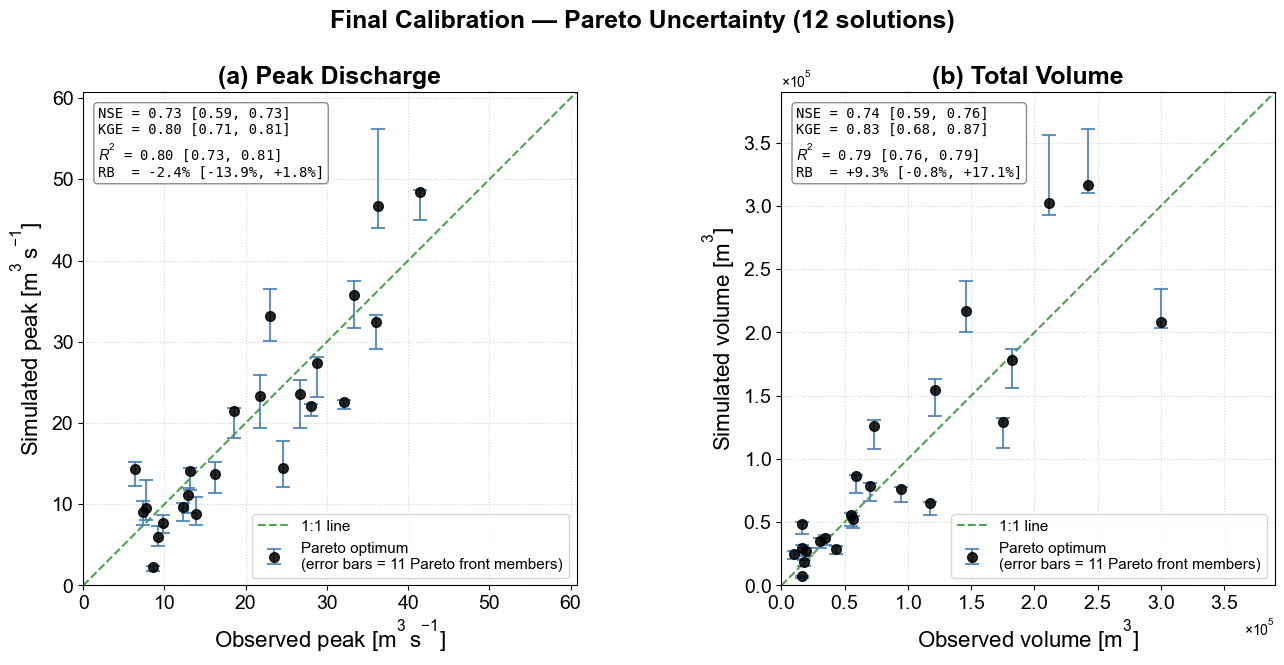

Saved -> outputs\metrics\pareto_uncertainty_scatter.png


In [13]:
# ── Section 2: Uncertainty Scatter Plot (obs vs sim, Pareto error bars) ────────

import scipy.stats
import hydroeval as he

# ── Font configuration ─────────────────────────────────────────────────────────
plt.rcParams['font.family']      = 'Arial'
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm']      = 'Arial'
plt.rcParams['mathtext.it']      = 'Arial:italic'
plt.rcParams['mathtext.bf']      = 'Arial:bold'

# ── Data preparation ───────────────────────────────────────────────────────────
_dates       = sorted(obs_hydrograph_df.index.get_level_values('Date').unique())
_obs_peaks_s = obs_hydrograph_df.groupby(level=0)['OBS runoff [CMS]'].max()
_obs_vols_s  = obs_hydrograph_df.groupby(level=0)['OBS runoff [CMS]'].sum() * 5 * 60

n_events  = len(_dates)
obs_peaks = np.array([float(_obs_peaks_s[d]) for d in _dates])
obs_vols  = np.array([float(_obs_vols_s[d])  for d in _dates])

# Simulated peaks and volumes for every Pareto member x every event.
# all_sim_peaks[j, i] = peak discharge [m³/s] for member j at event i.
# all_sim_vols[j, i]  = total volume   [m³]   for member j at event i.
all_sim_peaks = np.zeros((n_pareto, n_events))
all_sim_vols  = np.zeros((n_pareto, n_events))

for j, midx in enumerate(pareto_indices):
    for i, date in enumerate(_dates):
        all_sim_peaks[j, i] = float(cali_merged.loc[midx, (date, 'Max Runoff')])
        # Total Volume in cali_merged is a raw CMS sum — multiply by 300 s for m³
        all_sim_vols[j, i]  = float(cali_merged.loc[midx, (date, 'Total Volume')]) * 300.0

# Index of the chosen optimum within the ordered pareto_indices list
opt_j         = pareto_indices.index(optimum_idx)
sim_opt_peaks = all_sim_peaks[opt_j]
sim_opt_vols  = all_sim_vols[opt_j]

# Error bars: range of the OTHER (non-optimum) members only
_other_j      = [j for j in range(n_pareto) if j != opt_j]
peak_min_rest = all_sim_peaks[_other_j].min(axis=0)
peak_max_rest = all_sim_peaks[_other_j].max(axis=0)
vol_min_rest  = all_sim_vols[_other_j].min(axis=0)
vol_max_rest  = all_sim_vols[_other_j].max(axis=0)

peak_err_lo = np.maximum(0.0, sim_opt_peaks - peak_min_rest)
peak_err_hi = np.maximum(0.0, peak_max_rest - sim_opt_peaks)
vol_err_lo  = np.maximum(0.0, sim_opt_vols  - vol_min_rest)
vol_err_hi  = np.maximum(0.0, vol_max_rest  - sim_opt_vols)


# ── Ensemble metric computation ────────────────────────────────────────────────

def _member_metrics(obs, sim_2d):
    """Compute NSE, KGE, R², RB for each row of sim_2d versus obs."""
    n_mem    = sim_2d.shape[0]
    nse_arr  = np.zeros(n_mem)
    kge_arr  = np.zeros(n_mem)
    r2_arr   = np.zeros(n_mem)
    rb_arr   = np.zeros(n_mem)
    obs_f    = obs.astype(np.float64)
    obs_mean = max(float(obs_f.mean()), 1e-12)
    ss_tot   = float(np.sum((obs_f - obs_f.mean()) ** 2))
    for j in range(n_mem):
        sim        = sim_2d[j].astype(np.float64)
        nse_arr[j] = float(1.0 - np.sum((obs_f - sim) ** 2) / max(ss_tot, 1e-12))
        # he.evaluator returns shape (4, 1): row 0 = KGE, rows 1-3 = components
        kge_arr[j] = float(he.evaluator(he.kge, sim, obs_f)[0][0])
        r_val, _   = scipy.stats.pearsonr(obs_f, sim)
        r2_arr[j]  = float(r_val ** 2)
        rb_arr[j]  = (float(sim.mean()) - obs_mean) / obs_mean * 100.0
    return {'NSE': nse_arr, 'KGE': kge_arr, '$R^2$': r2_arr, 'RB': rb_arr}


def _format_ensemble_box(metrics, opt_j):
    """Build 4-line stats text: 'Metric = Opt [Min, Max]' for the stats box."""
    lines = []
    for name, vals in metrics.items():
        opt = float(vals[opt_j])
        lo  = float(vals.min())
        hi  = float(vals.max())
        if name == 'RB':
            lines.append(f'RB  = {opt:+.1f}% [{lo:+.1f}%, {hi:+.1f}%]')
        else:
            lines.append(f'{name} = {opt:.2f} [{lo:.2f}, {hi:.2f}]')
    return '\n'.join(lines)


peak_metrics    = _member_metrics(obs_peaks, all_sim_peaks)
vol_metrics     = _member_metrics(obs_vols,  all_sim_vols)
peak_stats_text = _format_ensemble_box(peak_metrics, opt_j)
vol_stats_text  = _format_ensemble_box(vol_metrics,  opt_j)

print('Peak metrics (Opt [Min, Max]):')
print(peak_stats_text)
print()
print('Volume metrics (Opt [Min, Max]):')
print(vol_stats_text)


# ── Plot ───────────────────────────────────────────────────────────────────────

fig, (ax_p, ax_v) = plt.subplots(1, 2, figsize=(14, 6.5))


def _scatter_with_errbar(ax, obs, sim_opt, err_lo, err_hi, stats_text,
                         xlabel, ylabel, label, vol_fmt=False):
    """Obs-vs-sim scatter: optimum dot + Pareto error bars + ensemble stats box."""
    _max = max(obs.max(), (sim_opt + err_hi).max()) * 1.08
    ax.plot([0, _max], [0, _max], 'g--', alpha=0.7, linewidth=1.5, label='1:1 line')
    ax.errorbar(
        obs, sim_opt,
        yerr=[err_lo, err_hi],
        fmt='ko', markersize=7,
        capsize=5, capthick=1.5,
        elinewidth=1.5, ecolor='steelblue', alpha=0.85,
        label=f'Pareto optimum\n(error bars = {len(_other_j)} Pareto front members)',
    )
    ax.text(
        0.03, 0.97, stats_text,
        transform=ax.transAxes, fontsize=10,      # ← קטן מ-13
        va='top', ha='left', family='monospace',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',  # ← pad קטן מ-0.4
                  edgecolor='gray', alpha=0.9),
    )
    ax.set_xlabel(xlabel, **LABEL_FONT)
    ax.set_ylabel(ylabel, **LABEL_FONT)

    # tick_params does not accept fontname — set labelsize separately,
    # then apply the font family directly to each tick label object.
    tick_kw = {k: v for k, v in TICK_FONT.items()
               if k in ('labelsize', 'size', 'color', 'direction',
                        'length', 'width', 'pad', 'zorder')}
    ax.tick_params(axis='both', **tick_kw)
    _font_name = TICK_FONT.get('fontname', TICK_FONT.get('family', 'Arial'))
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontname(_font_name)

    ax.set_xlim(0, _max)
    ax.set_ylim(0, _max)
    ax.set_aspect('equal', 'box')
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.legend(fontsize=11, loc='lower right')
    ax.set_title(label, **TITLE_FONT)
    if vol_fmt:
        _fmt = ScalarFormatter(useMathText=True)
        _fmt.set_powerlimits((-1, 4))
        ax.xaxis.set_major_formatter(_fmt)
        ax.yaxis.set_major_formatter(_fmt)


# Labels use mathtext ($...$) for superscripts — renders correctly with all fonts
_scatter_with_errbar(
    ax_p, obs_peaks, sim_opt_peaks, peak_err_lo, peak_err_hi,
    peak_stats_text,
    xlabel=r'Observed peak $[\mathrm{m^3\,s^{-1}}]$',
    ylabel=r'Simulated peak $[\mathrm{m^3\,s^{-1}}]$',
    label='(a) Peak Discharge',
)
_scatter_with_errbar(
    ax_v, obs_vols, sim_opt_vols, vol_err_lo, vol_err_hi,
    vol_stats_text,
    xlabel=r'Observed volume $[\mathrm{m^3}]$',
    ylabel=r'Simulated volume $[\mathrm{m^3}]$',
    label='(b) Total Volume',
    vol_fmt=True,
)

fig.suptitle(
    f'Final Calibration \u2014 Pareto Uncertainty ({n_pareto} solutions)',
    **TITLE_FONT, y=1.01,
)
plt.tight_layout()
_save_p2 = str(METRICS_DIR / 'pareto_uncertainty_scatter.png')
plt.savefig(_save_p2, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {_save_p2}')

In [14]:
# ── Section 3: Envelope Hydrographs — All 23 Events ──────────────────────────

plt.rcParams['font.family'] = 'Arial'

print(f'Generating {len(_dates)} uncertainty hydrographs -> {UNCERT_DIR}')

for _i, date in enumerate(_dates, 1):
    # Observed flow and rainfall
    event_obs = obs_hydrograph_df.xs(date, level='Date')
    obs_flow  = event_obs['OBS runoff [CMS]'].astype(np.float64).values
    rainfall  = event_obs['rainfall [mm/h]'].astype(np.float64).values

    # Simulated discharge for all Pareto members at this event
    sim_cols   = [c for c in hydro_merged.columns if c[0] == date]
    event_sim  = hydro_merged.loc[pareto_indices, sim_cols].astype(np.float64)
    sim_opt    = hydro_merged.loc[optimum_idx,    sim_cols].astype(np.float64).values

    # Min/max envelope across ALL Pareto members (including optimum)
    env_min = event_sim.min(axis=0).values
    env_max = event_sim.max(axis=0).values

    # Trim to the shortest common length
    n        = min(len(obs_flow), len(sim_opt), len(env_min), len(rainfall))
    obs_flow = obs_flow[:n]
    sim_opt  = sim_opt[:n]
    env_min  = env_min[:n]
    env_max  = env_max[:n]
    rainfall = rainfall[:n]
    x        = np.arange(n)

    fig, ax1 = plt.subplots(figsize=(13, 5))
    ax2 = ax1.twinx()

    # Rainfall bars: inverted, top of the frame
    ax2.bar(x, rainfall, color='steelblue', alpha=0.30, width=1.0, label='Rainfall [mm/h]')
    ax2.invert_yaxis()
    ax2.set_ylim(max(rainfall.max() * 3.5, 1.0), 0)
    ax2.set_ylabel('Rainfall [mm/h]', fontsize=14, color='steelblue')
    ax2.tick_params(axis='y', labelsize=12, colors='steelblue')
    ax2.spines['right'].set_edgecolor('steelblue')
    ax2.spines['right'].set_linewidth(1.2)

    # Pareto uncertainty envelope (fill between min and max)
    ax1.fill_between(
        x, env_min, env_max,
        alpha=0.30, color='orange',
        label=f'Pareto envelope (n={n_pareto})',
    )

    # Observed discharge (black solid) and optimum (red dashed)
    ax1.plot(x, obs_flow, color='black', linewidth=2.0, label='Observed')
    ax1.plot(x, sim_opt,  color='red',   linewidth=2.0, linestyle='--',
             label='Pareto optimum')

    ax1.set_xlabel('Time step [5 min]', fontsize=14)
    ax1.set_ylabel('Discharge [m\u00b3 s\u207b\u00b9]', fontsize=14)
    ax1.tick_params(axis='both', labelsize=12)
    ax1.set_xlim(0, n - 1)
    ax1.set_ylim(bottom=0)
    ax1.grid(True, linestyle=':', alpha=0.5)
    ax1.legend(fontsize=12, loc='upper right')
    ax1.set_title(
        f'Uncertainty Hydrograph  {date.replace("_", "-")}  |  Pareto ensemble',
        fontsize=15, fontweight='bold',
    )

    plt.tight_layout()
    _save = str(UNCERT_DIR / f'uncertainty_hydro_{date}.png')
    fig.savefig(_save, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f'  [{_i:2d}/{len(_dates)}] {date}  saved')

print(f'\nAll {len(_dates)} hydrographs saved to {UNCERT_DIR}')


Generating 23 uncertainty hydrographs -> outputs\metrics\uncertainty_hydrographs


C:\Users\raznu\AppData\Local\Temp\ipykernel_4184\3459931313.py:67: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\raznu\AppData\Local\Temp\ipykernel_4184\3459931313.py:69: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.savefig(_save, dpi=150, bbox_inches='tight')


  [ 1/23] 2012_01_13  saved


C:\Users\raznu\AppData\Local\Temp\ipykernel_4184\3459931313.py:67: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\raznu\AppData\Local\Temp\ipykernel_4184\3459931313.py:69: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.savefig(_save, dpi=150, bbox_inches='tight')


  [ 2/23] 2013_01_06  saved
  [ 3/23] 2014_12_14  saved


...

  [20/23] 2018_12_07  saved


C:\Users\raznu\AppData\Local\Temp\ipykernel_4184\3459931313.py:67: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\raznu\AppData\Local\Temp\ipykernel_4184\3459931313.py:69: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.savefig(_save, dpi=150, bbox_inches='tight')


  [21/23] 2019_12_13  saved
  [22/23] 2019_12_27  saved


C:\Users\raznu\AppData\Local\Temp\ipykernel_4184\3459931313.py:67: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\raznu\AppData\Local\Temp\ipykernel_4184\3459931313.py:69: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.savefig(_save, dpi=150, bbox_inches='tight')
C:\Users\raznu\AppData\Local\Temp\ipykernel_4184\3459931313.py:67: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\raznu\AppData\Local\Temp\ipykernel_4184\3459931313.py:69: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.savefig(_save, dpi=150, bbox_inches='tight')


  [23/23] 2020_01_19  saved

All 23 hydrographs saved to outputs\metrics\uncertainty_hydrographs


In [15]:
# ── Section 4: Uncertainty Quantification Metrics ─────────────────────────────

# P-factor: fraction of observed values contained within Pareto bounds.
# Bounds are computed over ALL Pareto members (including optimum).
all_peak_min = np.zeros(n_events)
all_peak_max = np.zeros(n_events)
all_vol_min  = np.zeros(n_events)
all_vol_max  = np.zeros(n_events)

for i, date in enumerate(_dates):
    peaks_all = cali_merged.loc[pareto_indices, (date, 'Max Runoff')].astype(float)
    vols_all  = cali_merged.loc[pareto_indices, (date, 'Total Volume')].astype(float) * 300.0
    all_peak_min[i] = peaks_all.min()
    all_peak_max[i] = peaks_all.max()
    all_vol_min[i]  = vols_all.min()
    all_vol_max[i]  = vols_all.max()

peak_in_bounds = int(((obs_peaks >= all_peak_min) & (obs_peaks <= all_peak_max)).sum())
vol_in_bounds  = int(((obs_vols  >= all_vol_min)  & (obs_vols  <= all_vol_max)).sum())
p_factor_peak  = peak_in_bounds / n_events * 100
p_factor_vol   = vol_in_bounds  / n_events * 100

# Average absolute width of the hydrograph envelope across all timesteps and events
envelope_widths_per_event = []
for date in _dates:
    sim_cols  = [c for c in hydro_merged.columns if c[0] == date]
    event_sim = hydro_merged.loc[pareto_indices, sim_cols].astype(np.float64)
    width_t   = (event_sim.max(axis=0) - event_sim.min(axis=0)).values
    obs_n     = len(obs_hydrograph_df.xs(date, level='Date'))
    envelope_widths_per_event.append(float(width_t[:obs_n].mean()))

mean_envelope_width = float(np.mean(envelope_widths_per_event))
std_envelope_width  = float(np.std(envelope_widths_per_event))

# ── Print summary ──────────────────────────────────────────────────────────────
print('=' * 56)
print('  PARETO UNCERTAINTY QUANTIFICATION METRICS')
print('=' * 56)
print()
print(f'  Pareto front size              : {n_pareto} solutions')
print()
print(f'  P-factor  (peak discharge)     : {p_factor_peak:.1f}%')
print(f'    {peak_in_bounds}/{n_events} events: observed peak within Pareto min-max bounds')
print()
print(f'  P-factor  (total volume)       : {p_factor_vol:.1f}%')
print(f'    {vol_in_bounds}/{n_events} events: observed volume within Pareto min-max bounds')
print()
print(f'  Mean hydrograph envelope width : {mean_envelope_width:.4f} m\u00b3 s\u207b\u00b9')
print(f'  Std  hydrograph envelope width : {std_envelope_width:.4f} m\u00b3 s\u207b\u00b9')
print()

# Per-event breakdown table
_peak_range    = all_peak_max - all_peak_min
_vol_range_m3  = (all_vol_max - all_vol_min)
_peak_inside   = (obs_peaks >= all_peak_min) & (obs_peaks <= all_peak_max)
_vol_inside    = (obs_vols  >= all_vol_min)  & (obs_vols  <= all_vol_max)

breakdown = pd.DataFrame({
    'Event':           _dates,
    'Obs peak':        np.round(obs_peaks, 3),
    'Peak min':        np.round(all_peak_min, 3),
    'Peak max':        np.round(all_peak_max, 3),
    'Peak range':      np.round(_peak_range, 3),
    'Peak inside':     _peak_inside,
    'Obs vol [m3]':    np.round(obs_vols, 0).astype(int),
    'Vol min [m3]':    np.round(all_vol_min, 0).astype(int),
    'Vol max [m3]':    np.round(all_vol_max, 0).astype(int),
    'Vol inside':      _vol_inside,
    'Env width [m3/s]':np.round(envelope_widths_per_event, 4),
})

print('Per-event breakdown:')
print(breakdown.to_string(index=False))
print()
print('=' * 56)


  PARETO UNCERTAINTY QUANTIFICATION METRICS

  Pareto front size              : 12 solutions

  P-factor  (peak discharge)     : 17.4%
    4/23 events: observed peak within Pareto min-max bounds

  P-factor  (total volume)       : 26.1%
    6/23 events: observed volume within Pareto min-max bounds

  Mean hydrograph envelope width : 0.5047 m³ s⁻¹
  Std  hydrograph envelope width : 0.3148 m³ s⁻¹

Per-event breakdown:
     Event  Obs peak  Peak min  Peak max  Peak range  Peak inside  Obs vol [m3]  Vol min [m3]  Vol max [m3]  Vol inside  Env width [m3/s]
2012_01_13    36.094    29.062    33.281       4.219        False        182181        156300        187200        True            0.1980
2013_01_06    36.281    44.031    56.250      12.219        False        242140        309900        361200       False            0.7477
2014_12_14     8.648     1.796     2.410       0.614        False         16569          6178          7505       False            0.1181
2015_10_07    13.852     7.3